# <center> Unit-Value Conversion

In [9]:
import pandas as pd
import json
import os
import numpy as np

In [10]:
country_codes = pd.read_csv('../../data/raw_trade_data/BACI_country_codes.csv')
country_codes

,country_code,country_name,country_iso2,country_iso3
0,4,Afghanistan,AF,AFG
1,8,Albania,AL,ALB
2,12,Algeria,DZ,DZA
3,16,American Samoa,AS,ASM
4,20,Andorra,AD,AND
...,...,...,...,...
225,862,Venezuela,VE,VEN
226,876,Wallis and Futuna Isds,WF,WLF
227,882,Samoa,WS,WSM
228,887,Yemen,YE,YEM


In [11]:
total_trade_volume = pd.read_csv('../../data/raw_trade_data/BACI_total_trade_volume_2024.csv')

# IMPORTANT: Convert v from thousands of USD to USD
total_trade_volume['v'] = total_trade_volume['v'] * 1000

total_trade_volume

,t,i,j,k,v,q
0,2024,4,24,80810,176.0,0.100
1,2024,4,24,330499,2295.0,0.230
2,2024,4,24,732510,5617.0,0.038
3,2024,4,24,848330,2420.0,0.004
4,2024,4,24,853610,605.0,0.011
...,...,...,...,...,...,...
11250406,2024,894,858,610429,585.0,0.003
11250407,2024,894,858,848490,48.0,0.001
11250408,2024,894,858,870810,20.0,0.001
11250409,2024,894,860,60420,415.0,0.115


In [12]:
# Data quality check: non-zero entries for v (value) and q (quantity)
n_total = len(total_trade_volume)

n_v_nonzero = (total_trade_volume['v'] > 0).sum()
n_q_nonzero = (total_trade_volume['q'].notna() & (total_trade_volume['q'] > 0)).sum()
n_both_nonzero = (
    (total_trade_volume['v'] > 0) &
    total_trade_volume['q'].notna() &
    (total_trade_volume['q'] > 0)
).sum()
n_q_nan = total_trade_volume['q'].isna().sum()
n_q_zero = ((total_trade_volume['q'] == 0) & total_trade_volume['q'].notna()).sum()

print(f"Total BACI rows:                       {n_total:>12,}")
print(f"Non-zero v (value, USD):               {n_v_nonzero:>12,}  ({100*n_v_nonzero/n_total:.1f}%)")
print(f"Non-zero q (quantity, metric tons):    {n_q_nonzero:>12,}  ({100*n_q_nonzero/n_total:.1f}%)")
print(f"  of which q is NaN:                   {n_q_nan:>12,}  ({100*n_q_nan/n_total:.1f}%)")
print(f"  of which q == 0:                     {n_q_zero:>12,}  ({100*n_q_zero/n_total:.1f}%)")
print(f"Both non-zero (usable for bilateral):  {n_both_nonzero:>12,}  ({100*n_both_nonzero/n_total:.1f}%)")

Total BACI rows:                         11,250,411
Non-zero v (value, USD):                 11,250,411  (100.0%)
Non-zero q (quantity, metric tons):      10,886,196  (96.8%)
  of which q is NaN:                        364,215  (3.2%)
  of which q == 0:                                0  (0.0%)
Both non-zero (usable for bilateral):    10,886,196  (96.8%)


In [13]:
# Create a copy to avoid modifying the original
df = total_trade_volume.copy()

# Extract HS 2-digit chapter from k
# For 5-digit codes (70310), take the first digit
# For 6-digit codes, take the first two digits
df['hs_chapter'] = df['k'].astype(str).apply(
    lambda x: int(x[0]) if len(x) == 5 else int(x[:2])
)

# Remove rows where weight (q) is NaN for conversion factor calculations
df_clean = df.dropna(subset=['q'])

# Merge with country codes to get country names for exporters and importers
df_clean = df_clean.merge(
    country_codes[['country_code', 'country_name']],
    left_on='i', right_on='country_code', how='left'
).rename(columns={'country_name': 'exporter_name'}).drop(columns=['country_code'])

df_clean = df_clean.merge(
    country_codes[['country_code', 'country_name']],
    left_on='j', right_on='country_code', how='left'
).rename(columns={'country_name': 'importer_name'}).drop(columns=['country_code'])

print("="*60)
print("PART 1: CREATING GENERAL CONVERSION FACTOR JSON FILE")
print("="*60)

# Create output directory if it doesn't exist
output_dir = 'trade_volume_conversion_output'
os.makedirs(output_dir, exist_ok=True)

# ===== GENERAL JSON: quantity-weighted average by HS chapter only =====
# conversion_factor = total_value_usd / total_weight_tons  (USD per metric ton)
# Uses only rows where q is not NaN (real measured quantities, not synthetic)
general_grouped = df_clean.groupby('hs_chapter').agg(
    v=('v', 'sum'),
    q=('q', 'sum')
).reset_index()
general_grouped['conversion_factor'] = general_grouped['v'] / general_grouped['q']
general_grouped = general_grouped[general_grouped['q'] > 0]

general_conversion_dict = {}
for _, row in general_grouped.iterrows():
    chapter = int(row['hs_chapter'])
    general_conversion_dict[chapter] = {
        'conversion_factor': float(row['conversion_factor']),
        'total_value_usd': float(row['v']),
        'total_weight_tons': float(row['q'])
    }

general_output_path = os.path.join(output_dir, 'trade_volume_conversion_general.json')
with open(general_output_path, 'w') as f:
    json.dump(general_conversion_dict, f, indent=2)

print(f"✓ General conversion factors exported to: {general_output_path}")
print(f"  Number of HS chapters: {len(general_grouped)}")

print("\n" + "="*60)
print("PART 1.5: SYNTHETIC FILL OF MISSING QUANTITY VALUES")
print("="*60)

# For rows where q is NaN, synthetically fill using the global (quantity-weighted)
# conversion factor for that HS chapter:  synthetic_q = v / cf_chapter
# This gives: tons = USD / (USD per ton)
# The CF used here is the total-global ratio (not an equal-weight average across countries).
ch_to_cf = df['hs_chapter'].map(
    {int(k): float(v['conversion_factor']) for k, v in general_conversion_dict.items()}
)
df['q_filled'] = df['q'].copy()
nan_q_mask = df['q_filled'].isna()
df.loc[nan_q_mask, 'q_filled'] = df.loc[nan_q_mask, 'v'] / ch_to_cf[nan_q_mask]
# Any remaining NaN (HS chapters with no measured quantities at all) → 0
df['q_filled'] = df['q_filled'].fillna(0.0)

n_filled = nan_q_mask.sum()
print(f"Filled {n_filled:,} rows ({100*n_filled/len(df):.1f}%) using HS chapter average CF")
print(f"Remaining zero q_filled entries: {(df['q_filled'] == 0).sum():,}")

print("\n" + "="*60)
print("PART 2: CREATING TRADE MATRICES (VALUE + WEIGHT)")
print("="*60)

# Get all unique countries (from both exporters and importers)
all_country_ids = pd.concat([df['i'], df['j']]).unique()
all_country_ids = sorted(all_country_ids)
country_map = dict(zip(country_codes['country_code'], country_codes['country_name']))
all_country_names = [country_map.get(cid, f"Unknown_{cid}") for cid in all_country_ids]

# Get all unique HS chapters
all_hs_chapters = sorted(df['hs_chapter'].unique())

# Create output directory for matrices
matrix_output_dir = '../../data/all_trade_matrices'
os.makedirs(matrix_output_dir, exist_ok=True)

def create_trade_matrix(trade_data, hs_chapter=None, value_col='v'):
    """
    Create a trade matrix for a specific HS chapter (or all trade if hs_chapter is None).

    Parameters
    ----------
    value_col : str
        Column to aggregate: 'v' for USD value, 'q_filled' for metric tons.

    Returns a DataFrame with World totals row/column.
    """
    if hs_chapter is not None:
        filtered_data = trade_data[trade_data['hs_chapter'] == hs_chapter].copy()
    else:
        filtered_data = trade_data.copy()

    trade_agg = filtered_data.groupby(['i', 'j'])[value_col].sum().reset_index()

    n_countries = len(all_country_ids)
    matrix = np.zeros((n_countries, n_countries))
    country_id_to_idx = {cid: idx for idx, cid in enumerate(all_country_ids)}

    for _, row in trade_agg.iterrows():
        exporter_idx = country_id_to_idx[row['i']]
        importer_idx = country_id_to_idx[row['j']]
        matrix[exporter_idx, importer_idx] = row[value_col]

    df_matrix = pd.DataFrame(matrix, index=all_country_names, columns=all_country_names)

    total_exports = df_matrix.sum(axis=1)
    total_imports = df_matrix.sum(axis=0)
    grand_total = total_exports.sum()

    df_matrix.insert(0, 'World', total_exports)
    world_row = pd.Series(['World'] + total_imports.tolist(), index=['World'] + all_country_names)
    world_row['World'] = grand_total
    df_matrix.loc['World'] = world_row
    df_matrix = df_matrix.reindex(['World'] + all_country_names)

    return df_matrix


# Create value + weight matrix for each HS chapter
print(f"\nCreating {len(all_hs_chapters)} HS chapter matrices (value + weight)...")
for hs_chapter in all_hs_chapters:
    value_matrix  = create_trade_matrix(df, hs_chapter=hs_chapter, value_col='v')
    weight_matrix = create_trade_matrix(df, hs_chapter=hs_chapter, value_col='q_filled')

    value_matrix.to_csv(os.path.join(matrix_output_dir, f'value_trade_matrix_all_transport_modes_HS{hs_chapter}.csv'))
    weight_matrix.to_csv(os.path.join(matrix_output_dir, f'weight_trade_matrix_all_transport_modes_HS{hs_chapter}.csv'))
    print(f"✓ HS{hs_chapter}: value + weight matrices saved")

# Create TOTAL matrices (all goods)
print(f"\nCreating TOTAL matrices (all goods)...")
total_value_matrix  = create_trade_matrix(df, hs_chapter=None, value_col='v')
total_weight_matrix = create_trade_matrix(df, hs_chapter=None, value_col='q_filled')

total_value_matrix.to_csv(os.path.join(matrix_output_dir, 'value_trade_matrix_all_transport_modes_TOTAL.csv'))
total_weight_matrix.to_csv(os.path.join(matrix_output_dir, 'weight_trade_matrix_all_transport_modes_TOTAL.csv'))

# Alias for backward compat with display cell below
total_matrix = total_value_matrix

print(f"✓ TOTAL value + weight matrices saved")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Conversion factors (general): {len(general_grouped)} HS chapters")
print(f"Value matrices:  {len(all_hs_chapters) + 1}  →  value_trade_matrix_all_transport_modes_HS*.csv")
print(f"Weight matrices: {len(all_hs_chapters) + 1}  →  weight_trade_matrix_all_transport_modes_HS*.csv")
print(f"Matrix dimensions: {len(all_country_names) + 1} x {len(all_country_names) + 1} (including World totals)")
print(f"\nAll outputs saved successfully!")

PART 1: CREATING GENERAL CONVERSION FACTOR JSON FILE
✓ General conversion factors exported to: trade_volume_conversion_output/trade_volume_conversion_general.json
  Number of HS chapters: 96

PART 1.5: SYNTHETIC FILL OF MISSING QUANTITY VALUES
Filled 364,215 rows (3.2%) using HS chapter average CF
Remaining zero q_filled entries: 0

PART 2: CREATING TRADE MATRICES (VALUE + WEIGHT)

Creating 96 HS chapter matrices (value + weight)...
✓ HS1: value + weight matrices saved
✓ HS2: value + weight matrices saved
✓ HS3: value + weight matrices saved
✓ HS4: value + weight matrices saved
✓ HS5: value + weight matrices saved
✓ HS6: value + weight matrices saved
✓ HS7: value + weight matrices saved
✓ HS8: value + weight matrices saved
✓ HS9: value + weight matrices saved
✓ HS10: value + weight matrices saved
✓ HS11: value + weight matrices saved
✓ HS12: value + weight matrices saved
✓ HS13: value + weight matrices saved
✓ HS14: value + weight matrices saved
✓ HS15: value + weight matrices saved
✓ 

In [14]:
print("="*60)
print("PART 3: BILATERAL CONVERSION FACTOR PERCENTILES")
print("="*60)
print("Computing per-(HS chapter, exporter, importer) conversion factors...")

# Aggregate BACI rows to (hs_chapter, exporter, importer) level
# Use df_clean which already has hs_chapter and has NaN-q rows removed
bilateral = (
    df_clean.groupby(['hs_chapter', 'i', 'j'])
    .agg(total_v=('v', 'sum'), total_q=('q', 'sum'))
    .reset_index()
)

# Keep only pairs where both value and quantity are positive
bilateral = bilateral[(bilateral['total_v'] > 0) & (bilateral['total_q'] > 0)].copy()
bilateral['cf'] = bilateral['total_v'] / bilateral['total_q']

print(f"Total (HS, exporter, importer) triples with valid bilateral CF: {len(bilateral):,}")

# Per HS chapter: 2.5th and 97.5th percentile across all country pairs
bilateral_percentiles = {}
for chapter, grp in bilateral.groupby('hs_chapter'):
    cfs = grp['cf'].values
    bilateral_percentiles[int(chapter)] = {
        'p2_5':   float(np.percentile(cfs, 2.5)),
        'median': float(np.median(cfs)),
        'p97_5':  float(np.percentile(cfs, 97.5)),
        'n_pairs': int(len(cfs)),
    }

# Save to JSON alongside the general conversion factors
bilateral_output_path = os.path.join(output_dir, 'trade_volume_conversion_bilateral_percentiles.json')
with open(bilateral_output_path, 'w') as f:
    json.dump(bilateral_percentiles, f, indent=2)

print(f"✓ Bilateral percentiles saved to: {bilateral_output_path}")
print(f"  HS chapters covered: {len(bilateral_percentiles)}")
print()
print("Sample (HS27 — Mineral Fuels):")
ch27 = bilateral_percentiles.get(27, {})
print(f"  p2.5={ch27.get('p2_5',0):,.0f}  median={ch27.get('median',0):,.0f}  p97.5={ch27.get('p97_5',0):,.0f}  n_pairs={ch27.get('n_pairs',0):,}")

PART 3: BILATERAL CONVERSION FACTOR PERCENTILES
Computing per-(HS chapter, exporter, importer) conversion factors...
Total (HS, exporter, importer) triples with valid bilateral CF: 852,620
✓ Bilateral percentiles saved to: trade_volume_conversion_output/trade_volume_conversion_bilateral_percentiles.json
  HS chapters covered: 96

Sample (HS27 — Mineral Fuels):
  p2.5=125  median=1,075  p97.5=68,593  n_pairs=10,565


In [15]:
total_matrix

,World,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Azerbaijan,Argentina,...,United Rep. of Tanzania,USA,Burkina Faso,Uruguay,Uzbekistan,Venezuela,Wallis and Futuna Isds,Samoa,Yemen,Zambia
World,2.294449e+13,5.722131e+09,9.716229e+09,4.362147e+10,253973205.0,1.870279e+09,1.453677e+10,996406517.0,2.430098e+10,5.963871e+10,...,2.054845e+10,3.132249e+12,6.277812e+09,1.316590e+10,3.781628e+10,1.365706e+10,56161897.0,549286818.0,8.796308e+09,1.191985e+10
Afghanistan,1.615215e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,1.157700e+04,0.0,3.456100e+04,5.943000e+03,...,2.289700e+04,2.280259e+07,1.600700e+04,3.099800e+04,4.467351e+07,0.000000e+00,0.0,0.0,0.000000e+00,7.110000e+02
Albania,3.930716e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,2.556000e+05,0.0,6.280380e+05,5.068450e+05,...,9.079000e+03,1.127567e+08,3.125600e+04,2.135150e+05,1.591399e+06,0.000000e+00,0.0,0.0,0.000000e+00,2.297000e+03
Algeria,4.803961e+10,0.000000e+00,5.847804e+07,0.000000e+00,0.0,0.000000e+00,1.334722e+06,0.0,1.353696e+06,1.312338e+08,...,3.568390e+05,2.514824e+09,4.896629e+06,6.738944e+07,1.170200e+04,0.000000e+00,0.0,0.0,0.000000e+00,1.184000e+03
American Samoa,3.253870e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,8.088000e+03,0.000000e+00,...,4.468500e+04,0.000000e+00,0.000000e+00,6.867000e+03,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,4.893019e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,1.360920e+10,0.000000e+00,2.123900e+04,0.000000e+00,0.0,0.000000e+00,1.790000e+03,0.0,2.645000e+03,5.770594e+06,...,2.809000e+03,6.299941e+09,0.000000e+00,2.451720e+05,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,1.948900e+04
Wallis and Futuna Isds,3.432030e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,...,0.000000e+00,2.593100e+04,5.920000e+02,7.700000e+01,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00
Samoa,3.983571e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,5.360000e+02,...,0.000000e+00,4.848954e+06,0.000000e+00,1.187000e+03,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00
Yemen,6.613977e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,1.580000e+02,0.0,0.000000e+00,0.000000e+00,...,2.324230e+05,9.169568e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.000000e+00,0.000000e+00


## China Trade Flow — Sankey Visualization

China sits in the centre. **Left bars** are countries that export to China (bar height = their total global exports); flows show China's imports from each. **Right bars** are countries that import from China (bar height = their total global imports); flows show China's exports to each. The red **Trade Surplus** bar on the left fills the gap between China's imports and its (larger) exports. All values in USD (2024 BACI data).

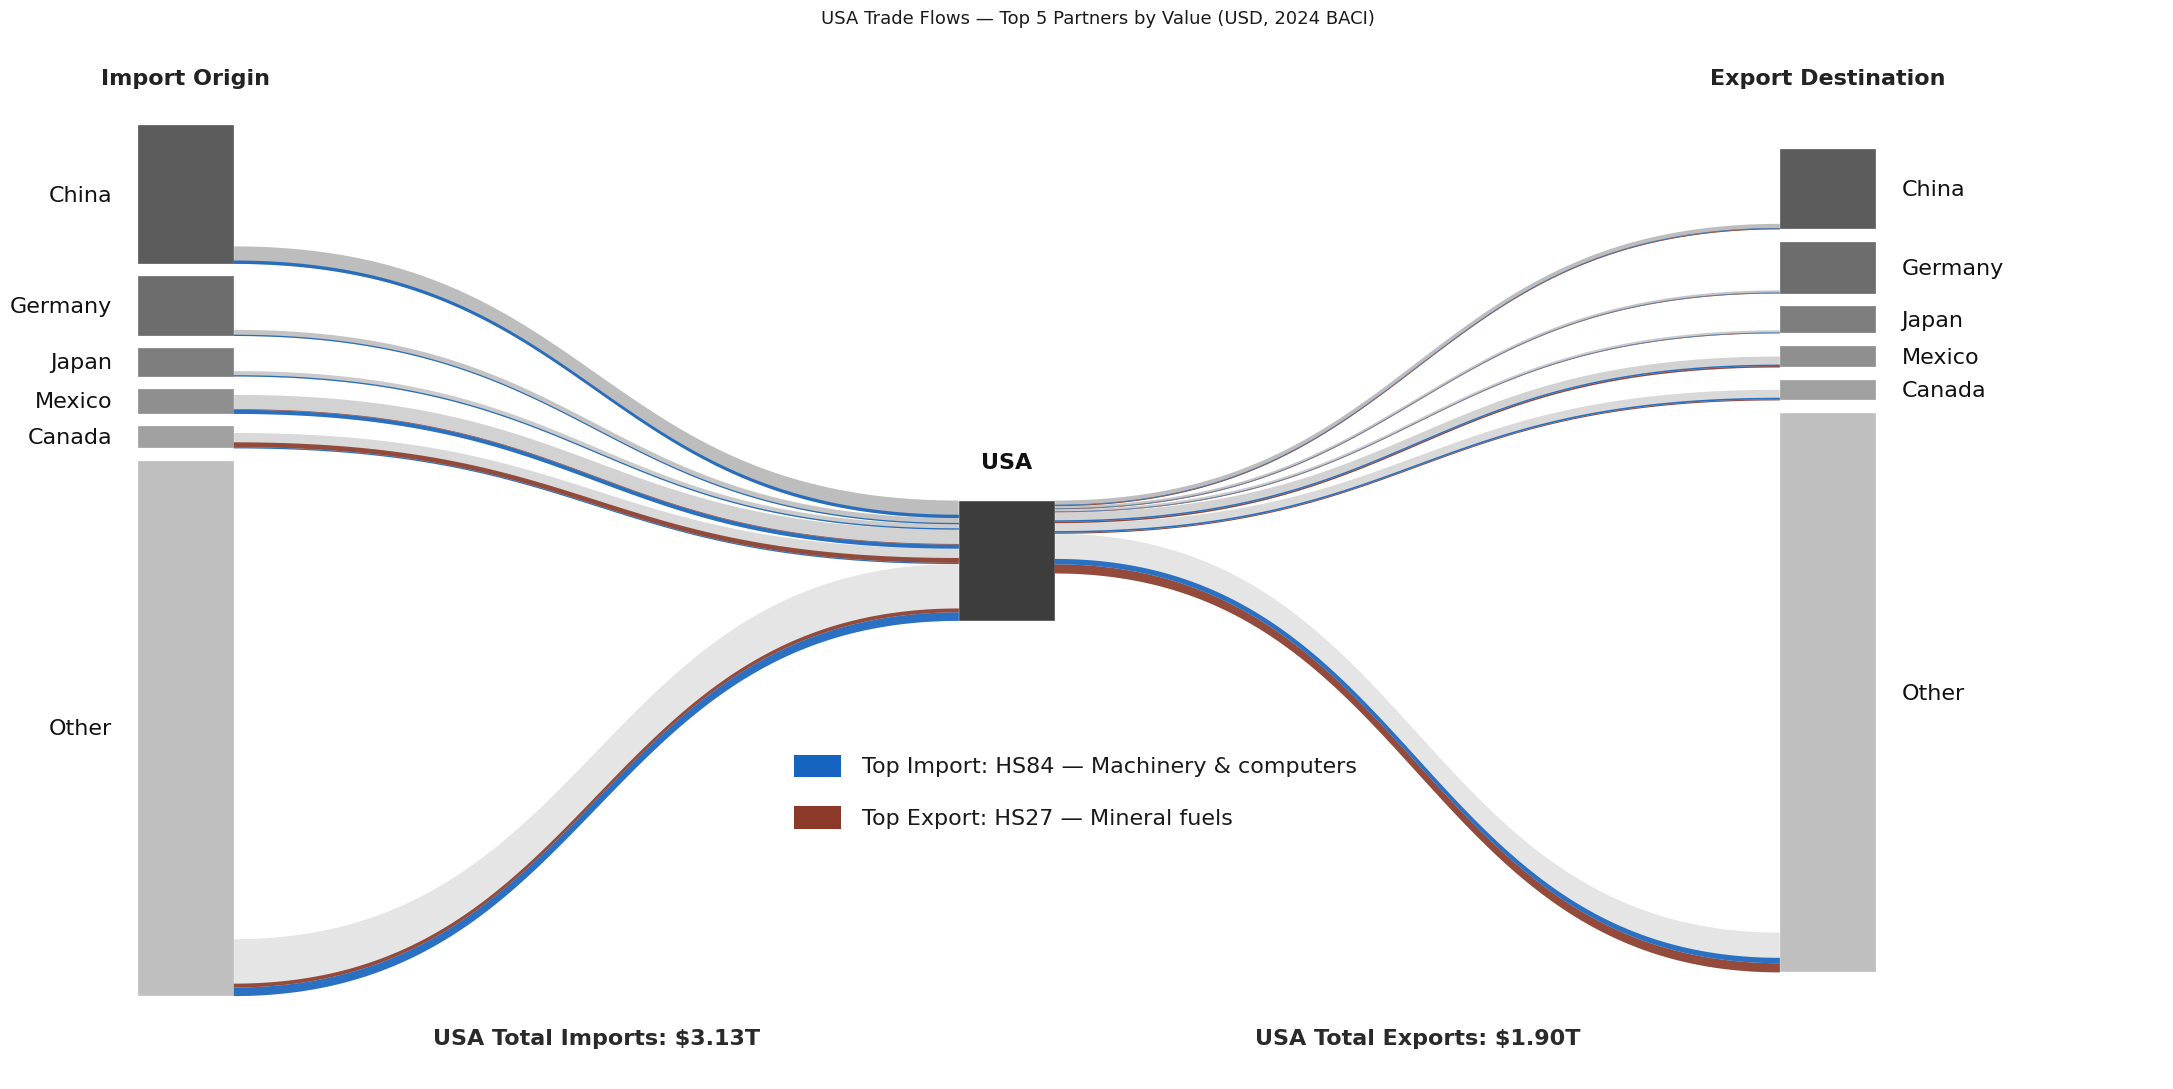

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# Colours from Simulation_Visualizations.ipynb (HS_COLORS)
HS_COLORS = {27: '#8B3A2A', 84: '#1565C0'}
HS_NAMES  = {27: 'HS27 — Mineral fuels', 84: 'HS84 — Machinery & computers'}

LABEL_SIZE = 16

vm = total_value_matrix.drop('World', axis=0, errors='ignore').drop('World', axis=1, errors='ignore')

FOCUS = 'USA'
EXCL  = {'USA'}

focus_ex = vm.loc[FOCUS].drop([c for c in EXCL if c in vm.columns], errors='ignore')
focus_im = vm[FOCUS].drop([c for c in EXCL if c in vm.index], errors='ignore')

top5_ex = focus_ex.nlargest(5)
top5_im = focus_im.nlargest(5)

exp_by_country = vm.sum(axis=1)
imp_by_country = vm.sum(axis=0)

focus_X = float(exp_by_country[FOCUS])
focus_M = float(imp_by_country[FOCUS])

other_M_flow = focus_M - float(top5_im.sum())
other_X_flow = focus_X - float(top5_ex.sum())

excl_L = EXCL | set(top5_im.index)
excl_R = EXCL | set(top5_ex.index)
other_L_bar = float(exp_by_country.drop([c for c in excl_L if c in exp_by_country.index], errors='ignore').sum())
other_R_bar = float(imp_by_country.drop([c for c in excl_R if c in imp_by_country.index], errors='ignore').sum())

def fmt(v):
    return f"${v/1e12:.2f}T" if v >= 1e12 else f"${v/1e9:.0f}B"

MAT = '../../data/all_trade_matrices'
def load_hs(ch):
    df = pd.read_csv(f'{MAT}/value_trade_matrix_all_transport_modes_HS{ch}.csv', index_col=0)
    return df.drop('World', axis=0, errors='ignore').drop('World', axis=1, errors='ignore')

vm84 = load_hs(84)   # HS84 Machinery
vm27 = load_hs(27)   # HS27 Mineral fuels

left_order = (
    sorted([(c, float(exp_by_country[c]), float(top5_im[c])) for c in top5_im.index],
           key=lambda x: -x[1])
    + [('Other', other_L_bar, other_M_flow)]
)
right_order = (
    sorted([(c, float(imp_by_country[c]), float(top5_ex[c])) for c in top5_ex.index],
           key=lambda x: -x[1])
    + [('Other', other_R_bar, other_X_flow)]
)

named_L = [n for n, _, _ in left_order  if n != 'Other']
named_R = [n for n, _, _ in right_order if n != 'Other']

def hs_bilateral(partner, df_hs, named_excl, row_is_focus=False):
    """Generic: flow for a partner where FOCUS is either the column (import) or row (export)."""
    if partner == 'Other':
        if row_is_focus:
            total = float(df_hs.loc[FOCUS].sum()) if FOCUS in df_hs.index else 0.0
            known = sum(float(df_hs.loc[FOCUS, c]) for c in named_excl
                        if c in df_hs.columns and FOCUS in df_hs.index)
        else:
            total = float(df_hs[FOCUS].sum()) if FOCUS in df_hs.columns else 0.0
            known = sum(float(df_hs.loc[c, FOCUS]) for c in named_excl
                        if c in df_hs.index and FOCUS in df_hs.columns)
        return max(0.0, total - known)
    if row_is_focus:
        return float(df_hs.loc[FOCUS, partner]) if FOCUS in df_hs.index and partner in df_hs.columns else 0.0
    else:
        return float(df_hs.loc[partner, FOCUS]) if partner in df_hs.index and FOCUS in df_hs.columns else 0.0

# Imports: partner -> USA  (row=partner, col=FOCUS)
hs84_im = {n: hs_bilateral(n, vm84, named_L, row_is_focus=False) for n, _, _ in left_order}
hs27_im = {n: hs_bilateral(n, vm27, named_L, row_is_focus=False) for n, _, _ in left_order}

# Exports: USA -> partner  (row=FOCUS, col=partner)
hs84_ex = {n: hs_bilateral(n, vm84, named_R, row_is_focus=True)  for n, _, _ in right_order}
hs27_ex = {n: hs_bilateral(n, vm27, named_R, row_is_focus=True)  for n, _, _ in right_order}

GAP   = 0.012
AVAIL = 0.84   # leaves ~0.08 padding top and bottom for labels
n_L, n_R = len(left_order), len(right_order)
total_L = sum(b for _, b, _ in left_order)
total_R = sum(b for _, b, _ in right_order)

sf = min(
    (AVAIL - GAP * (n_L - 1)) / total_L,
    (AVAIL - GAP * (n_R - 1)) / total_R,
)

focus_bar_h = focus_M * sf     # bar sized by IMPORTS
focus_ex_h  = focus_X * sf

def make_positions(order):
    total_h = sum(b * sf for _, b, _ in order) + GAP * (len(order) - 1)
    y, pos = 0.5 + total_h / 2, {}
    for name, bar_usd, _ in order:
        h = bar_usd * sf
        pos[name] = (y - h, y)
        y -= h + GAP
    return pos

left_pos  = make_positions(left_order)
right_pos = make_positions(right_order)

focus_y_top = 0.5 + focus_bar_h / 2
focus_y_bot = 0.5 - focus_bar_h / 2

# Import slots: full bar, top -> bottom
focus_L = {}
y = focus_y_top
for name, _, flow_usd in left_order:
    h = flow_usd * sf
    focus_L[name] = (y - h, y)
    y -= h

# Export slots: top portion only, top -> bottom
focus_R = {}
y = focus_y_top
for name, _, flow_usd in right_order:
    h = flow_usd * sf
    focus_R[name] = (y - h, y)
    y -= h

def draw_flow(ax, x0, yb0, yt0, x1, yb1, yt1, color, alpha=0.40, zorder=1):
    t  = np.linspace(0, 1, 300)
    mx = (x0 + x1) / 2
    bx = (1-t)**3*x0 + 3*(1-t)**2*t*mx + 3*(1-t)*t**2*mx + t**3*x1
    by = (1-t)**3*yb0 + 3*(1-t)**2*t*yb0 + 3*(1-t)*t**2*yb1 + t**3*yb1
    ty = (1-t)**3*yt0 + 3*(1-t)**2*t*yt0 + 3*(1-t)*t**2*yt1 + t**3*yt1
    ax.fill(np.concatenate([bx, bx[::-1]]), np.concatenate([by, ty[::-1]]),
            color=color, alpha=alpha, lw=0, zorder=zorder)

GREYS = ['#5c5c5c', '#6d6d6d', '#7e7e7e', '#8f8f8f', '#a0a0a0']

# Wider horizontal spacing
LX, LW = 0.05, 0.045
CX, CW = 0.435, 0.045
RX, RW = 0.82, 0.045

fig, ax = plt.subplots(figsize=(22, 11))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
fig.patch.set_facecolor('white')

# USA bar
ax.add_patch(patches.Rectangle(
    (CX, focus_y_bot), CW, focus_bar_h, fc='#3d3d3d', ec='white', lw=0.3, zorder=3
))
ax.text(CX + CW / 2, focus_y_top + 0.028, FOCUS,
        ha='center', va='bottom', fontsize=LABEL_SIZE, fontweight='bold', color='#111111')

# Summary labels
ax.text((LX + LW + CX) / 2, 0.03,
        f'USA Total Imports: {fmt(focus_M)}',
        ha='center', va='bottom', fontsize=LABEL_SIZE, fontweight='bold', color='#2a2a2a')
ax.text((CX + CW + RX) / 2, 0.03,
        f'USA Total Exports: {fmt(focus_X)}',
        ha='center', va='bottom', fontsize=LABEL_SIZE, fontweight='bold', color='#2a2a2a')

# Left bars + grey flows
for i, (name, bar_usd, flow_usd) in enumerate(left_order):
    y_bot, y_top   = left_pos[name]
    cs_bot, cs_top = focus_L[name]
    bar_c = '#bfbfbf' if name == 'Other' else GREYS[i % len(GREYS)]
    ax.add_patch(patches.Rectangle(
        (LX, y_bot), LW, y_top - y_bot, fc=bar_c, ec='white', lw=0.2, zorder=3
    ))
    h_f = flow_usd * sf
    draw_flow(ax, LX + LW, y_bot, y_bot + h_f, CX, cs_bot, cs_top, color=bar_c, zorder=2)
    ax.text(LX - 0.012, (y_bot + y_top) / 2, name,
            ha='right', va='center', fontsize=LABEL_SIZE, color='#111111')

# HS84 overlay on left (top import: Machinery) — draw ABOVE HS27
for name, _, flow_usd in left_order:
    y_bot, _  = left_pos[name]
    cs_bot, _ = focus_L[name]
    hs_val    = hs84_im[name]
    if hs_val <= 0: continue
    hs_h = hs_val * sf
    draw_flow(ax, LX + LW, y_bot, y_bot + hs_h, CX, cs_bot, cs_bot + hs_h,
              color=HS_COLORS[84], alpha=0.90, zorder=4)

# HS27 overlay on left (also imported, shown below HS84 strip)
for name, _, flow_usd in left_order:
    y_bot, _  = left_pos[name]
    cs_bot, _ = focus_L[name]
    hs84_val  = hs84_im[name]
    hs27_val  = hs27_im[name]
    if hs27_val <= 0: continue
    # stack HS27 above HS84 within the flow band
    offset = hs84_val * sf
    hs_h   = hs27_val * sf
    draw_flow(ax, LX + LW, y_bot + offset, y_bot + offset + hs_h,
              CX, cs_bot + offset, cs_bot + offset + hs_h,
              color=HS_COLORS[27], alpha=0.90, zorder=4)

# Right bars + grey flows
for i, (name, bar_usd, flow_usd) in enumerate(right_order):
    y_bot, y_top   = right_pos[name]
    cs_bot, cs_top = focus_R[name]
    bar_c = '#bfbfbf' if name == 'Other' else GREYS[i % len(GREYS)]
    ax.add_patch(patches.Rectangle(
        (RX, y_bot), RW, y_top - y_bot, fc=bar_c, ec='white', lw=0.2, zorder=3
    ))
    h_f = flow_usd * sf
    draw_flow(ax, CX + CW, cs_bot, cs_top, RX, y_bot, y_bot + h_f, color=bar_c, zorder=2)
    ax.text(RX + RW + 0.012, (y_bot + y_top) / 2, name,
            ha='left', va='center', fontsize=LABEL_SIZE, color='#111111')

# HS27 overlay on right (top export: Mineral fuels)
for name, _, flow_usd in right_order:
    y_bot, _  = right_pos[name]
    cs_bot, _ = focus_R[name]
    hs_val    = hs27_ex[name]
    if hs_val <= 0: continue
    hs_h = hs_val * sf
    draw_flow(ax, CX + CW, cs_bot, cs_bot + hs_h, RX, y_bot, y_bot + hs_h,
              color=HS_COLORS[27], alpha=0.90, zorder=4)

# HS84 overlay on right (also exported, stacked above HS27)
for name, _, flow_usd in right_order:
    y_bot, _  = right_pos[name]
    cs_bot, _ = focus_R[name]
    hs27_val  = hs27_ex[name]
    hs84_val  = hs84_ex[name]
    if hs84_val <= 0: continue
    offset = hs27_val * sf
    hs_h   = hs84_val * sf
    draw_flow(ax, CX + CW, cs_bot + offset, cs_bot + offset + hs_h,
              RX, y_bot + offset, y_bot + offset + hs_h,
              color=HS_COLORS[84], alpha=0.90, zorder=4)

# Column headers — high up, whitespace gap created by lowering bars
ax.text(LX + LW / 2, 0.975, 'Import Origin',
        ha='center', va='top', fontsize=LABEL_SIZE, fontweight='bold', color='#222222')
ax.text(RX + RW / 2, 0.975, 'Export Destination',
        ha='center', va='top', fontsize=LABEL_SIZE, fontweight='bold', color='#222222')

# HS legend — two rows stacked, centered below USA bar
legend_cx  = CX + CW / 2
legend_y1  = focus_y_bot - 0.14   # first row
legend_y2  = focus_y_bot - 0.19   # second row
swatch_w, swatch_h = 0.022, 0.022
swatch_offset = 0.10   # how far left of center the swatch starts

for row, ch in enumerate([84, 27]):
    ly = legend_y1 if row == 0 else legend_y2
    sx = legend_cx - swatch_offset
    ax.add_patch(patches.Rectangle(
        (sx, ly - swatch_h / 2), swatch_w, swatch_h,
        fc=HS_COLORS[ch], ec='none', zorder=6
    ))
    side  = 'Top Import' if ch == 84 else 'Top Export'
    label = f'{side}: {HS_NAMES[ch]}'
    ax.text(sx + swatch_w + 0.010, ly,
            label, ha='left', va='center', fontsize=LABEL_SIZE, color='#1a1a1a')

ax.set_title("USA Trade Flows — Top 5 Partners by Value (USD, 2024 BACI)",
             fontsize=13, pad=14, color='#1a1a1a')
plt.tight_layout()
plt.show()
